# Café Analytics - Descriptive Analysis

In [1]:
import pandas as pd
import warnings
import numpy as np
from datetime import datetime, date, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

In [2]:
# Ignore all warnings in output
warnings.filterwarnings('ignore')

In [3]:
# Set the maximum column width for pandas DataFrame display
pd.set_option('max_colwidth', 2000)

In [4]:
# Load the CSV file into a pandas DataFrame and 
# parse the 'order_time' column as datetime
df = pd.read_parquet(
    './cafe_processed_files/cafe_full_mx.parquet',
)

## Revenue Trend Analysis

In [5]:
df_revenue = df[
    ['order_id', 'customer_id', 'order_price', 'order_time']
].drop_duplicates().reset_index(drop=True)

In [6]:
df_revenue.head()

,order_id,customer_id,order_price,order_time
0,11787,517,12.8,2021-04-14 06:15:00
1,40606,519,12.8,2024-03-05 10:17:23
2,40488,519,12.8,2024-03-01 11:40:58
3,38252,519,12.8,2023-12-05 08:49:24
4,13470,776,12.8,2021-06-20 12:11:09


In [7]:
df_revenue['order_year'] = (
    df_revenue['order_time'].dt.year
)
df_revenue['order_month'] = (
    df_revenue['order_time'].dt.month
)
df_revenue['order_day'] = (
    df_revenue['order_time'].dt.day
)
df_revenue['order_dow'] = (
    df_revenue['order_time'].dt.dayofweek
)
df_revenue['order_hour'] = (
    df_revenue['order_time'].dt.hour
)

In [8]:
df_revenue['FY'] = (
    df_revenue.apply(
        lambda x: 'FY' + str(x['order_year'])[-2:] if x['order_month'] < 7
        else 'FY' + str(x['order_year'] + 1)[-2:],
        axis=1,
    )
)

In [9]:
df_revenue.head()

,order_id,customer_id,order_price,order_time,order_year,order_month,order_day,order_dow,order_hour,FY
0,11787,517,12.8,2021-04-14 06:15:00,2021,4,14,2,6,FY21
1,40606,519,12.8,2024-03-05 10:17:23,2024,3,5,1,10,FY24
2,40488,519,12.8,2024-03-01 11:40:58,2024,3,1,4,11,FY24
3,38252,519,12.8,2023-12-05 08:49:24,2023,12,5,1,8,FY24
4,13470,776,12.8,2021-06-20 12:11:09,2021,6,20,6,12,FY21


### Monthly Revenue Trend

In [10]:
monthly = (
    df_revenue[
        ['order_year', 'order_month', 'order_price']
    ].groupby(['order_year', 'order_month']).sum()
    .reset_index(drop=False)
)

In [11]:
monthly.head()

,order_year,order_month,order_price
0,2019,5,533.33
1,2019,6,124.30
2,2019,8,512.10
3,2019,9,359.00
4,2019,10,953.30


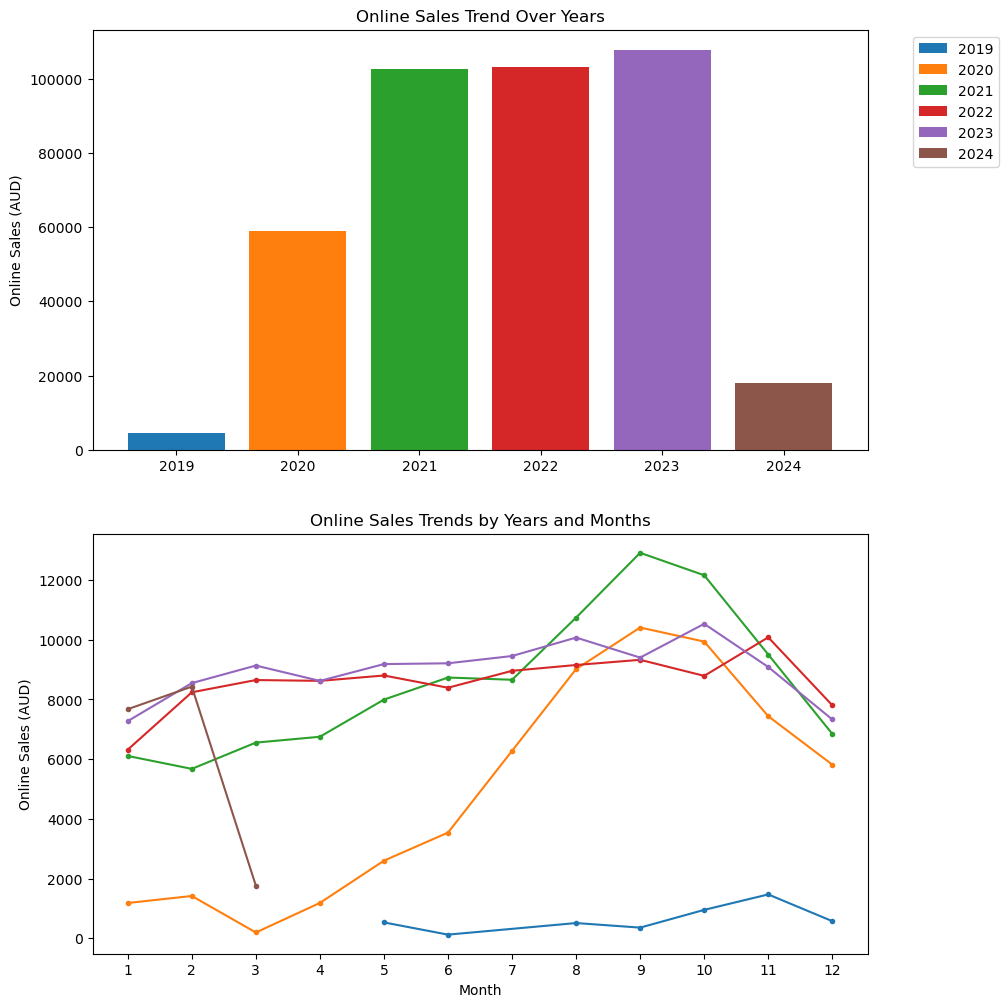

In [39]:
# Plot monthly revenue trend
fig, axes = plt.subplots(nrows=2, figsize=(10, 12))

for year in sorted(monthly['order_year'].unique()):
    month_data = monthly[
        monthly['order_year'] == year
    ]
    Y = month_data['order_price']
    X = month_data['order_month']
    
    axes[1].plot(X, Y, label=year, marker='.')
    axes[0].bar(
        x=year,
        height=month_data['order_price'].sum(), 
        label=year,
    )

axes[0].set_title('Online Sales Trend Over Years')
axes[0].legend(loc='upper left', bbox_to_anchor=(1.05, 1))
axes[0].set_xlabel('')
axes[0].set_ylabel('Online Sales (AUD)')
axes[1].set_title('Online Sales Trends by Years and Months')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Online Sales (AUD)')
axes[1].set_xticks(range(1, 13, 1))
plt.show()

* The bar chart above illustrates a **consistent rise** in business online sales from 2020 to 2023.
* Online sales in 2020 and 2021 consistently outperformed their corresponding previous year across all months, showing a notable increase during the winter season (June to August) and peaking in September before declining.
* In 2022, online sales generally stabilized over the course of the year but stayed higher than in 2021, except during the period from August to October. 
* Similary, online sales in 2023 remained stable overall but generally exceeded those of 2022 throughout the year.
* However, neither 2022 nor 2023 reached the September peak achieved in 2020 and 2021.

Question to investigate:<br><br>
**1) What factors contributed to the surge in sales from June to September in 2020 and 2021?**<br>
**2) Why did sales in 2022 and 2023 fail to reach the same peak in September?**<br>

Possible reasons: 

The **COVID pandemic lockdowns** likely boosted online sales, making the 2020 and 2021 figures more reflective of total sales (including both online and in-store). In contrast, the stablized sales in 2022 and 2023 may represent online sales only, as in-store shopping resumed.

As seen in the 2020 and 2021 figures, the café's online sales typically rise during the colder months from June to September in Australia, followed by a decline as the weather warms.

**TBC...**

### Most Profitable Day of the Week

In [13]:
total_revenue_per_day = (
    df_revenue[
        ['order_year', 'order_month', 'order_day', 
         'order_dow', 'order_price']
    ].groupby([
        'order_year', 'order_month', 
        'order_day', 'order_dow'
    ]).sum().reset_index(drop=False)
)

total_revenue_per_day.head()

,order_year,order_month,order_day,order_dow,order_price
0,2019,5,5,6,3.5
1,2019,5,6,0,31.0
2,2019,5,7,1,39.8
3,2019,5,10,4,18.7
4,2019,5,11,5,18.5


In [40]:
dow_revenue = (
    total_revenue_per_day[
        ['order_dow', 'order_price']
    ].groupby('order_dow').mean()
    .reset_index(drop=False)
)

dow_revenue

,order_dow,order_price
0,0,211.021468
1,1,222.690411
2,2,226.813426
3,3,238.064747
4,4,290.439908
5,5,312.957964
6,6,307.668128


In [16]:
day_of_week = {
    0: 'Mon',
    1: 'Tue',
    2: 'Wed',
    3: 'Thu',
    4: 'Fri',
    5: 'Sat',
    6: 'Sun',
}

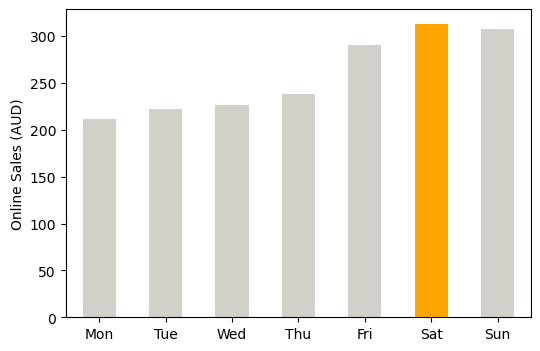

In [58]:
# Plot average daily revenue over a week
fig, ax = plt.subplots(figsize=(6, 4))

dow_revenue.plot.bar(
    x='order_dow', y='order_price', 
    color='#D3D0C9', ax=ax
)

# Highlight the most profitable day of the week
top_dow = dow_revenue[
    (
        dow_revenue['order_price'] 
        == dow_revenue['order_price'].max() 
    )
]
ax.bar(
    x=top_dow['order_dow'],
    height=top_dow['order_price'],
    color='orange',
    width=0.5,
)

plt.xticks(
    ticks=list(day_of_week.keys()),
    labels=list(day_of_week.values()), 
    rotation=0,
)
plt.xlabel('')
ax.get_legend().remove()
ax.set_ylabel('Online Sales (AUD)')
plt.show()

As shown in the bar charts above, the average daily online sales generally remained steady from Mondays to Thursdays, but rose higher during Fridays and weekends, with a peak on **Saturdays** and **Sundays**.

### Peak Revenue Hours

In [20]:
df_revenue.head()

,order_id,customer_id,order_price,order_time,order_year,order_month,order_day,order_dow,order_hour,FY
0,11787,517,12.8,2021-04-14 06:15:00,2021,4,14,2,6,FY21
1,40606,519,12.8,2024-03-05 10:17:23,2024,3,5,1,10,FY24
2,40488,519,12.8,2024-03-01 11:40:58,2024,3,1,4,11,FY24
3,38252,519,12.8,2023-12-05 08:49:24,2023,12,5,1,8,FY24
4,13470,776,12.8,2021-06-20 12:11:09,2021,6,20,6,12,FY21


In [21]:
# Group sales revenue by year, month, day and hour
total_revenue_per_hour = (
    df_revenue[
        ['order_year', 'order_month', 'order_day', 
         'order_hour', 'order_price']
    ].groupby([
        'order_year', 'order_month', 
        'order_day', 'order_hour'
    ]).sum().reset_index(drop=False)
)

In [22]:
print(total_revenue_per_hour.shape)
total_revenue_per_hour.head()

(10129, 5)


,order_year,order_month,order_day,order_hour,order_price
0,2019,5,5,22,3.5
1,2019,5,6,6,10.5
2,2019,5,6,11,15.5
3,2019,5,6,16,1.5
4,2019,5,6,17,3.5


In [23]:
# Display operating hours
sorted(total_revenue_per_hour['order_hour'].unique())

[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22]

Some of order-taking hours seem unusual for a café. Let's check whether there are any outliers (irregular ordering hours) among them.

#### Identify and Remove Outliers

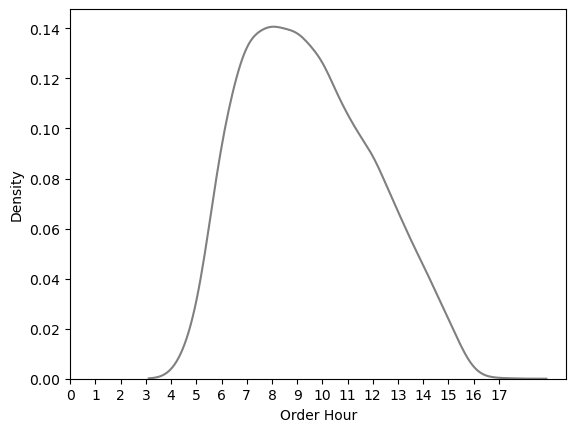

In [59]:
# Plot the KDE distribution of records across operating hours
fig, ax = plt.subplots()
sns.kdeplot(
    x=total_revenue_per_hour['order_hour'],
    bw_adjust=1.6,  
    color='gray',
    ax=ax,
)
ax.set_xlabel('Order Hour')
ax.set_xticks(
    range(
        0,
        total_revenue_per_hour['order_hour'].max() + 1,
        1,
    )
)
plt.show()

According to the Kernel Density Estimation (KDE) plot above, the ordering hours in most days are between 5AM to 3PM. Let's confirm this using a boxplot and identify any potential outliers.

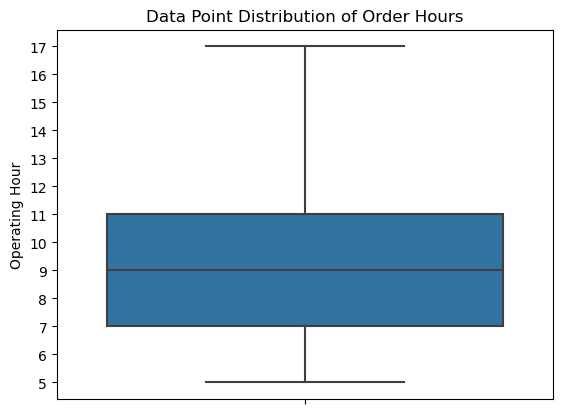

In [60]:
# Draw a boxplot to identify outliers of order hours
fig, ax = plt.subplots()
sns.boxplot(
    y=total_revenue_per_hour['order_hour'],
    whis=1.5,    # Set the whiskers to extend up to 1.5 times the interquartile range (IQR)
    ax=ax,
)
plt.title("Data Point Distribution of Order Hours")
plt.ylabel('Operating Hour')
plt.yticks(
    range(
        total_revenue_per_hour['order_hour'].min(),
        total_revenue_per_hour['order_hour'].max() + 1,
        1,
    )
)
plt.show()

As shown in the boxplot above, it appears that the ordering hours extending past 5 PM have been identified as outliers.

In [26]:
# Calculate the 1st quartile
Q1 = total_revenue_per_hour['order_hour'].quantile(0.25)
# Calculate the 3rd quartile
Q3 = total_revenue_per_hour['order_hour'].quantile(0.75)
# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Calculate the lower bound where the lower whisker ends
lower_bound = Q1 - 1.5 * IQR
# Calculate the upper bound where the upper whisker ends
upper_bound = Q3 + 1.5 * IQR

print(lower_bound)
print(upper_bound)

1.0
17.0


Data points falling below the lower bound or above the upper bound are considered **outliers**. Let's apply the lower and upper bounds to filter out irregular ordering hours, which only occurred on a few days in the business history, and determine the actual online ordering hours.

In [27]:
# Filter out irregular ordering hours
total_revenue_per_hour = total_revenue_per_hour[
    (total_revenue_per_hour['order_hour'] >= lower_bound)
    & (total_revenue_per_hour['order_hour'] <= upper_bound)
]

In [28]:
# Print the actual online ordering hours
sorted(total_revenue_per_hour['order_hour'].unique())

[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]

After filtering out the irregular ordering hours, we can see that the café typically accepts orders from **5 AM to 5 PM** on regular business days.

In [29]:
# Calculate the average online sales revenue per hour
hourly_revenue = (
    total_revenue_per_hour[
        ['order_hour', 'order_price']
    ].groupby('order_hour').mean()
    .reset_index(drop=False)
)

hourly_revenue

,order_hour,order_price
0,5,8.354428
1,6,29.992079
2,7,46.013722
3,8,60.106134
4,9,52.851500
5,10,40.142902
6,11,29.335843
7,12,30.914286
8,13,22.781949
9,14,15.505652


In [30]:
# Calculate the average revenue per hour across all days
avg_revenue_per_hour = total_revenue_per_hour['order_price'].mean()
print(avg_revenue_per_hour)

39.006592256025286


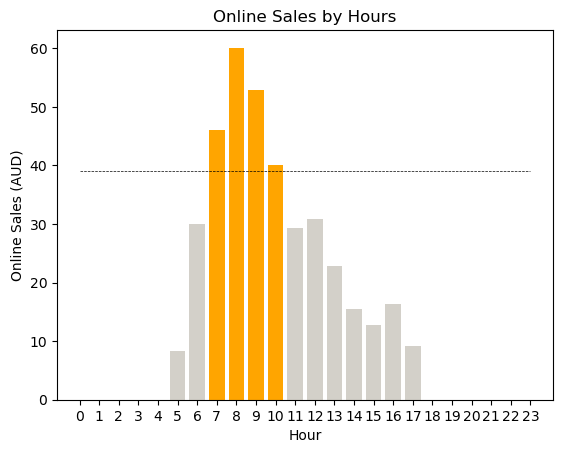

In [61]:
# Plot average hourly revenue across hours
plt.bar(
    x=hourly_revenue['order_hour'],
    height=hourly_revenue['order_price'],
    color='#D3D0C9',
)
# Plot a constant line representing average revenue per 
# hour across all days
plt.plot(
    range(0, 24, 1),
    [avg_revenue_per_hour] * 24,
    linestyle='--',
    linewidth=0.5,
    c='black',
)

# Highlight the peak revenue hours
top_revenue = hourly_revenue[
    hourly_revenue['order_price'] > avg_revenue_per_hour
]

plt.bar(
    x=top_revenue['order_hour'],
    height=top_revenue['order_price'],
    color='orange',
)
plt.title('Online Sales by Hours')
plt.xlabel('Hour')
plt.ylabel('Online Sales (AUD)')
plt.xticks(range(0, 24, 1))
plt.show()

The peak revenue hours that drive online sales above average are typically between **7 AM and 10 AM**, with the highest sales occurring at **8AM**.

### Revenue and Order Value per Customer

In [32]:
df_revenue.head()

,order_id,customer_id,order_price,order_time,order_year,order_month,order_day,order_dow,order_hour,FY
0,11787,517,12.8,2021-04-14 06:15:00,2021,4,14,2,6,FY21
1,40606,519,12.8,2024-03-05 10:17:23,2024,3,5,1,10,FY24
2,40488,519,12.8,2024-03-01 11:40:58,2024,3,1,4,11,FY24
3,38252,519,12.8,2023-12-05 08:49:24,2023,12,5,1,8,FY24
4,13470,776,12.8,2021-06-20 12:11:09,2021,6,20,6,12,FY21


In [33]:
cust_revenue = df_revenue[
    ['customer_id', 'order_year', 'order_month', 'order_id', 'order_price']
].sort_values(
    ['customer_id', 'order_year', 'order_month', 'order_id', 'order_price'],
    ascending=[True, True, True, True, True],
).reset_index(drop=True)

cust_revenue.head(10)

,customer_id,order_year,order_month,order_id,order_price
0,4,2019,5,3270,3.5
1,4,2019,5,3271,3.5
2,4,2019,5,3272,3.5
3,4,2019,5,3273,3.5
4,5,2019,5,3276,4.0
5,5,2019,5,3277,3.5
6,5,2019,5,3278,3.5
7,5,2019,5,3279,1.5
8,5,2019,5,3280,1.5
9,5,2019,5,3281,1.5


In [62]:
# Create a DataFrame showing total sales revenue contributed by 
# each customer over the entire business history in Descending order
total_sales_per_cust = (
    cust_revenue[
        ['customer_id', 'order_price']
    ].groupby('customer_id')
    .sum().sort_values('order_price', ascending=False)
    .rename(columns={'order_price': 'total_sales'})
    .reset_index(drop=False)
)
# Calculate the average total sales contributed by each customer
avg_total_sales = total_sales_per_cust['total_sales'].mean()

# Create a DataFrame showing the average spending per order by each
# customer in Descending order
spending_per_order_per_cust = (
    cust_revenue[
        ['customer_id', 'order_price']
    ].groupby('customer_id')
    .mean().sort_values('order_price', ascending=False)
    .rename(columns={'order_price': 'spending_per_order'})
    .reset_index(drop=False)
)
# Calculate average customer spending on one order
avg_spending_per_order = (
    spending_per_order_per_cust['spending_per_order'].mean()
)

# Create a DataFrame showing total number of orders for each customer
# in Descending order
total_orders_per_cust = (
    cust_revenue[
        ['customer_id', 'order_price']
    ].groupby('customer_id')
    .count().sort_values('order_price', ascending=False)
    .rename(columns={'order_price': 'order_count'})
    .reset_index(drop=False)
)
# Calculate average number of orders placed by each customer
avg_total_orders = (
    total_orders_per_cust['order_count'].mean()
)

In [63]:
print(
    "The average total sales contributed by each customer "
    "over their customer lifespan: ${}"
    .format(
        round(avg_total_sales, 2),
    )
)
total_sales_per_cust.head()

The average total sales contributed by each customer over their customer lifespan: $253.04


,customer_id,total_sales
0,9,11090.86
1,69,9535.39
2,234,8633.42
3,172,7851.24
4,191,6655.50


In [64]:
print(
    "The average customer spending per order: ${}".format(
        round(avg_spending_per_order, 2)
    )
)
spending_per_order_per_cust.head()

The average customer spending per order: $17.32


,customer_id,spending_per_order
0,1284,135.0
1,903,95.6
2,1242,94.0
3,1083,88.5
4,800,88.0


In [65]:
print(
    "The average number of orders placed by each customer "
    "over their customer lifespan: {}".format(
        round(avg_total_orders)
    )
)
total_orders_per_cust.head()

The average number of orders placed by each customer over their customer lifespan: 23


,customer_id,order_count
0,172,1036
1,9,972
2,195,937
3,234,840
4,191,688


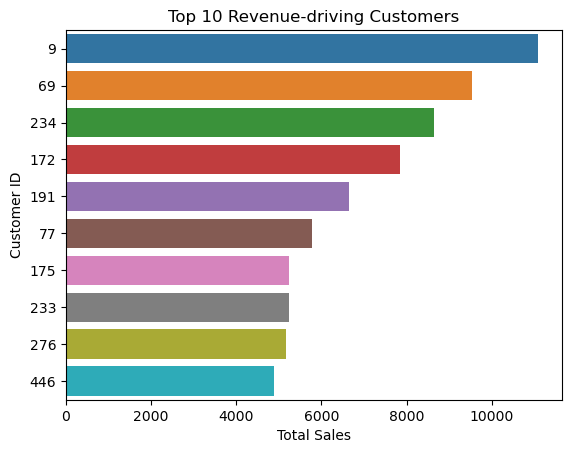

In [66]:
top10_total_sales = total_sales_per_cust.head(10)

fig, ax = plt.subplots()

sns.barplot(
    data=top10_total_sales,
    x='total_sales',
    y='customer_id',
    orient='h',
    order=top10_total_sales['customer_id'],
    ax=ax,
)

ax.set_title('Top 10 Revenue-driving Customers')
ax.set_ylabel('Customer ID')
ax.set_xlabel('Total Sales')

plt.show()

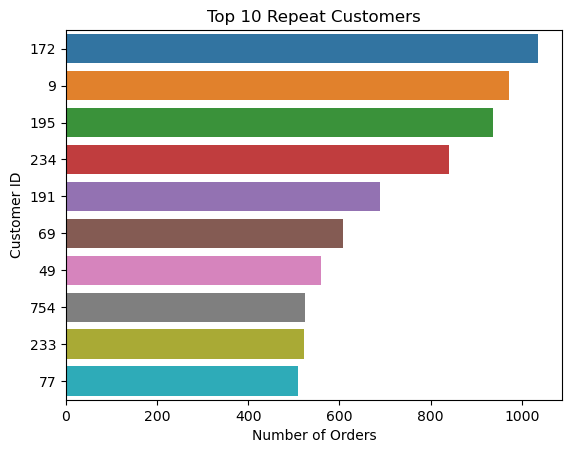

In [67]:
top10_order_count = total_orders_per_cust.head(10)

fig, ax = plt.subplots()

sns.barplot(
    data=top10_order_count,
    x='order_count',
    y='customer_id',
    orient='h',
    order=top10_order_count['customer_id'],
    ax=ax,
)

ax.set_title('Top 10 Repeat Customers')
ax.set_ylabel('Customer ID')
ax.set_xlabel('Number of Orders')

plt.show()

In [68]:
top10_sales_contributors = top10_total_sales['customer_id']

top10_frequent_buyers = top10_order_count['customer_id']

print(
    '{} out of the top 10 repeat customers are also '
    'among the top 10 sales-driving customers.'.format(
        len(
            [
                cust for cust in list(top10_frequent_buyers) 
                if cust in list(top10_sales_contributors)
            ]
        )
    )
)

7 out of the top 10 repeat customers are also among the top 10 sales-driving customers.


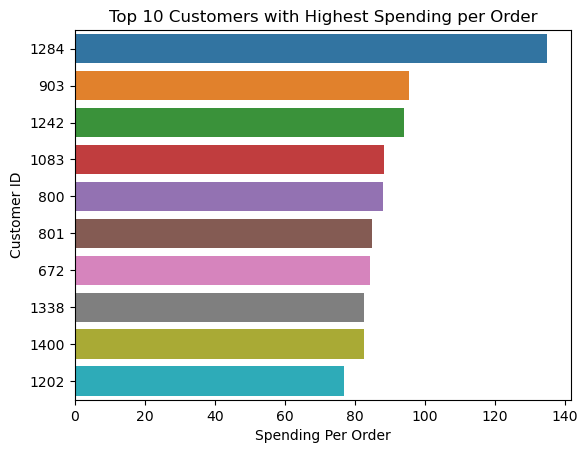

In [69]:
top10_spending_per_order = spending_per_order_per_cust.head(10)

fig, ax = plt.subplots()

sns.barplot(
    data=top10_spending_per_order,
    x='spending_per_order',
    y='customer_id',
    orient='h',
    order=top10_spending_per_order['customer_id'],
    ax=ax,
)

ax.set_title('Top 10 Customers with Highest Spending per Order')
ax.set_ylabel('Customer ID')
ax.set_xlabel('Spending Per Order')

plt.show()

In [70]:
top10_sales_contributors = top10_total_sales['customer_id']

top10_spenders = top10_spending_per_order['customer_id']

print(
    '{} out of the top 10 customers with highest spending per order are also '
    'among the top 10 sales-driving customers.'.format(
        len(
            [
                cust for cust in list(top10_spenders) 
                if cust in list(top10_sales_contributors)
            ]
        )
    )
)

0 out of the top 10 customers with highest spending per order are also among the top 10 sales-driving customers.


In [71]:
order_count = total_orders_per_cust[
    total_orders_per_cust['customer_id'].isin(
        top10_sales_contributors
    )
]
spending_per_order =  spending_per_order_per_cust[
    spending_per_order_per_cust['customer_id'].isin(
        top10_sales_contributors
    )
]
spending_per_order.merge(
    order_count,
    how='inner',
    on='customer_id',
)

,customer_id,spending_per_order,order_count
0,276,16.257862,318
1,69,15.683207,608
2,175,13.155578,398
3,9,11.410350,972
4,77,11.357996,509
5,446,11.214690,435
6,234,10.277881,840
7,233,10.018276,522
8,191,9.673692,688
9,172,7.578417,1036


#### Discuss Insights:

7 out of the top 10 revenue-generating customers are also among the top 10 repeat customers; however, none are in the top 10 for highest spending per order. All of them have placed more orders than the average of 23, but have spent less per order than the mean of $17.32.

These observations suggest that customer revenue may be more strongly correlated with the total number of orders placed than with the average spending per order. To verify this, let's examine the **correlation coefficients** between these variables.

#### Determine Correlation Method

There are two common types of correlation coefficients we can calculate: **Pearson Correlation Coefficients** and **Spearman's Rank Correlation Coefficients**. Each method has specific assumptions:
* **Pearson Correlation Coefficients**:
    - The variables are normally distribtued
    - The relationship between the variables is **linear**
* **Spearman's Rank Correlation Coefficients**:
    - The data is not normally distributed
    - The relationship between variables is **monotonic** (consistently increases or decreases but not necessarily at a constant rate) but not necessarily linear
    - The data may contain outliers that could affect Pearson's correlation
    
Let's investigate the customer revenue data to determine which correlation method to use.

In [72]:
df_corr = total_sales_per_cust.merge(
    total_orders_per_cust,
    how='inner',
    on='customer_id',
).merge(
    spending_per_order_per_cust,
    how='inner',
    on='customer_id',
)

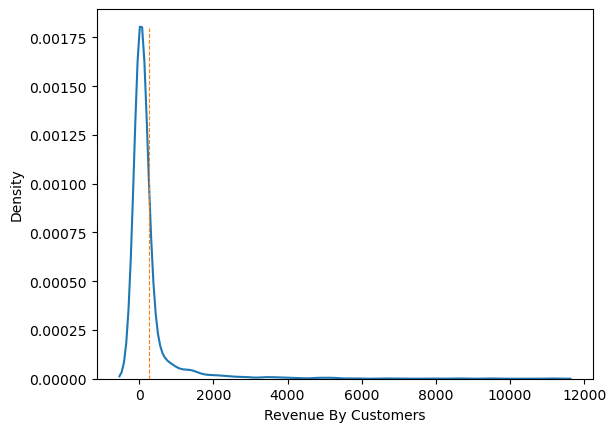

In [73]:
# Plot kernel density distribution of revenue by customers
fig, ax = plt.subplots()
sns.kdeplot(data=df_corr, x='total_sales', ax=ax)
# Plot the mean of revenue by customers as a constant line
ax.plot(
    [df_corr['total_sales'].mean(), df_corr['total_sales'].mean()], 
    [0, 0.0018],
    linestyle='--',
    linewidth=0.8,
)
plt.xlabel('Revenue By Customers')
plt.show()

According to the Kernal Density Estimation plot above, the `total_sales` variable is NOT normally distributed (it is right-skewed) and contains outliers. Therefore, we can calculate the **Spearman's Rank Correlation Coefficients** to determine the correlations between `total_sales` and `order_count`, and between `total_sales` and `spending_per_order`.

#### Calculate Spearman's Rank Correlation Coefficients

In [74]:
# Compute Spearman's Rank Correlation Coefficients matrix 
# between 'total_sales', 'order_count' and 'spending_per_order'
df_corr[
    ['total_sales', 'order_count', 'spending_per_order']
].corr(method='spearman')

,total_sales,order_count,spending_per_order
total_sales,1.000000,0.848067,0.395176
order_count,0.848067,1.000000,-0.090716
spending_per_order,0.395176,-0.090716,1.000000


The **relatively high** correlation coefficient of **0.848067** between `total_sales` and `order_count` indicates a **strong positive monotonic relationship** between these two variables. This suggests that as the total number of orders increases, the total sales tend to increase as well. The high coefficient value signifies that customers who place more orders generally contribute more to the total sales.

In contrast, the **relatively low** correlation coefficient (**0.395176**) between `total_sales` and `spending_per_order` indicates a **moderate positive monotonic relationship**. This means there is a weaker correlation between total sales and the average spending per order. While higher spending per order is somewhat associated with higher total sales, the relationship is not as strong or consistent as with the number of orders.

To determine whether the correlations between `total_sales` and `order_count`, and between `total_sales` and `spending_per_order` are statistically significant, we can perform **Hypothesis Test** on the Spearman's Rank Correlation Coefficients. This will help us assess the **level of confidence** we can place in the observed relationships.

#### Hypothesis Testing on Spearman's Rank Correlation Coefficients

**Hypotheses for `total sales` vs. `order_count`**

* Null Hypothesis ($H_0$): There is no monotonic relationship between `total_sales` and `order_count` ($\rho = 0$)
* Alternative Hypothesis ($H_1$): There is a statistically significant monotonic relationship between `total_sales` and `order_count` ($\rho\neq0$)

**Hypotheses for `total sales` vs. `spending_per_order`**

* Null Hypothesis ($H_0$): There is no monotonic relationship between `total_sales` and `spending_per_order` ($\rho = 0$)
* Alternative Hypothesis ($H_1$): There is a statistically significant monotonic relationship between `total_sales` and `spending_per_order` ($\rho\neq0$)

**Significance Level ($\alpha$)**: 0.05

We will use the **Spearman's Rank Correlation Coefficients** and calculate the corresponding **p-value** to assess the **statistical significance** of the correlation. The p-value represents the probability of observing the data assuming that the null hypothesis is true. By convention, we set the **significance level** ($\alpha$) at **0.05**.

Spearman correlation coefficient between total_sales and order_count: 0.8480669739387877
p-value: 0.0


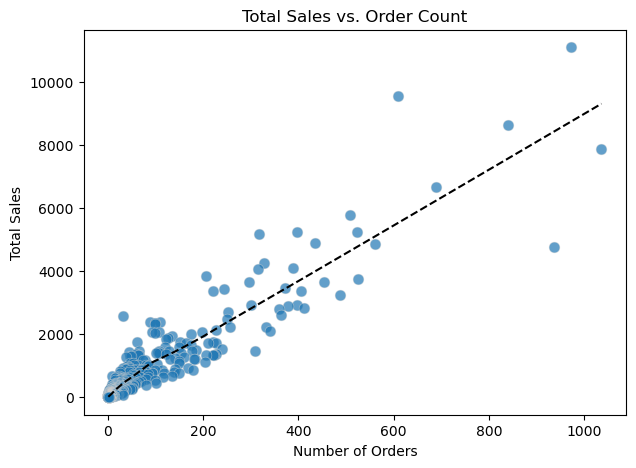

In [113]:
total_sales = df_corr['total_sales']
order_count = df_corr['order_count']

# Calculate Spearman's Rank Correlation and p-value
# for total_sales vs. order_count
corr_coefficient_ts_or, p_value_ts_oc = spearmanr(
    total_sales, order_count
)

print('Spearman correlation coefficient between '
      f'total_sales and order_count: {corr_coefficient_ts_or}')
print(f'p-value: {p_value_ts_oc}')

# Scatter plot for total_sales vs. order_count
plt.figure(figsize=(7, 5))
plt.scatter(
    order_count, 
    total_sales, 
    edgecolors='#d3d3d3',
    s=60,
    linewidth=0.4,
    alpha=0.7,
)
# Adding a LOWESS line to represent a monotonic trend
sns.regplot(
    x=order_count, 
    y=total_sales, 
    lowess=True, 
    scatter=False, 
    color='black',
    line_kws={
        'linewidth': 1.5,
        'linestyle': '--',
    },
)
plt.xlabel('Number of Orders')
plt.ylabel('Total Sales')
plt.title('Total Sales vs. Order Count')
plt.show()

Spearman correlation coefficient between total_sales and spending_per_order: 0.3951761660214768
p-value: 1.6797106660232876e-59


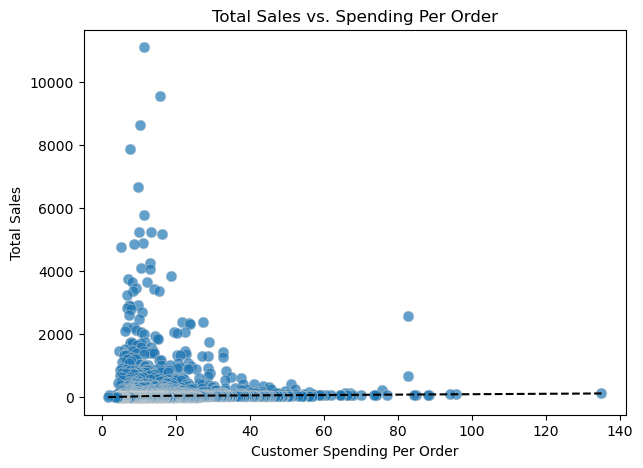

In [112]:
total_sales = df_corr['total_sales']
spending_per_order = df_corr['spending_per_order']

# Calculate Spearman's Rank Correlation and p-value
# for total_sales vs. spending_per_order
corr_coefficient_ts_sp, p_value_ts_sp = spearmanr(
    total_sales, spending_per_order
)

print('Spearman correlation coefficient between '
      f'total_sales and spending_per_order: {corr_coefficient_ts_sp}')
print(f'p-value: {p_value_ts_sp}')

# Scatter plot for total_sales vs spending_per_order
plt.figure(figsize=(7, 5))
plt.scatter(
    spending_per_order, 
    total_sales, 
    edgecolors='#d3d3d3',
    s=60,
    linewidth=0.4,
    alpha=0.7,
)
# Adding a LOWESS line to represent a monotonic trend
sns.regplot(
    x=spending_per_order, 
    y=total_sales, 
    lowess=True, 
    scatter=False, 
    color='black',
    line_kws={
        'linewidth': 1.5,
        'linestyle': '--',
    },
)
plt.xlabel('Customer Spending Per Order')
plt.ylabel('Total Sales')
plt.title('Total Sales vs. Spending Per Order')
plt.show()

**Conclusion**:

* **Total Sales vs. Number of Orders**:
    - Spearman's Rank Correlation Coefficient: **0.848**
        * Indicates a **strong positive monotonic relationship** between total sales and the number of orders
    - P-value: **0.0**
        * Since the p-value < 0.05, we **reject the null hypothesis**.
        * There is a **0% chance** that the observed correlation is due to randomness.
        * The strong positive correlation is **statistically significant**.
<br><br>
* **Total Sales vs. Spending per Order**:
    - Spearman's Rank Correlation Coefficient: **0.395**.
        * Indicates a **moderate positive monotonic relationship** between total sales and customer spending per order.
    - P-value: **1.68e-59**
        * Since the p-value < 0.05, we **reject the null hypothesis**.
        * There is an **extremely low chance** (effectively 0%) that the observed correlation is due to randomness.
        * The moderate positive correlation is **statistically significant**.

#### Summary

Due to the non-normal distribution of the variables, we used **Spearman's Rank Correlation** to assess the direction, strength, and statistical significance of the **monotonic relationships** between total sales and the number of orders, as well as between total sales and customer spending per order. Both correlations are **positive** and **statistically significant** at the 0.05 significance level, reinforcing the validity of observed relationships. We are now **confident** that:

* There is a **strong positive monotonic relationship** between total sales and the number of orders. As the number of orders increases, total sales tend to increase accordingly.

* There is a **moderate positive monotonic relationship** between total sales and customer spending per order. Higher spending per order is somewhat associated with increased total sales, but this relationship is not as strong as with the number of orders.

This analysis suggests that **repeat customers contribute more significantly to total sales** than customers who make high-value purchases per order. Therefore, implementing business strategies (e.g. loyalty program, repeat purchase incentives) aimed at **enhancing customer retention**, especially among the most loyal customers, and **encouraging them to place more orders**, is likely to be more effecitve in boosting total online sales than efforts focused on increasing their average spending per order.